# Exploratory analysis of MTSamples dataset for cleaning 

MTSamples contains the data taken from a clinical consultation in varying templates depending on the speciality transcribing. It holds clear Keyword linked information, speciality information, and a short description. This data will be used to build a simple NLP model which extract entities for easy tagging and medical summarisation. It will conform to SNOMED-CT classification for diagnosis. This notebook explores the structure and quality of the dataset to inform the cleaning decisions implemented in data_cleaning.py.

# Dependencies 

In [2]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
%matplotlib inline

In [38]:
df = pd.read_csv("../data/raw/mtsamples.csv", index_col=0)

In [42]:
df.columns, df.shape

(Index(['description', 'medical_specialty', 'sample_name', 'transcription',
        'keywords', 'transcription_length'],
       dtype='str'),
 (4999, 6))

In [43]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords,transcription_length
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331.0
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431.0
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422.0
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495.0
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618.0


In [44]:
df['transcription_length'] = df['transcription'].str.len()

In [45]:
df['transcription_length'].describe()

count     4966.000000
mean      3052.314337
std       1994.082239
min         11.000000
25%       1608.000000
50%       2667.000000
75%       4011.000000
max      18425.000000
Name: transcription_length, dtype: float64

<Axes: xlabel='transcription_length', ylabel='Count'>

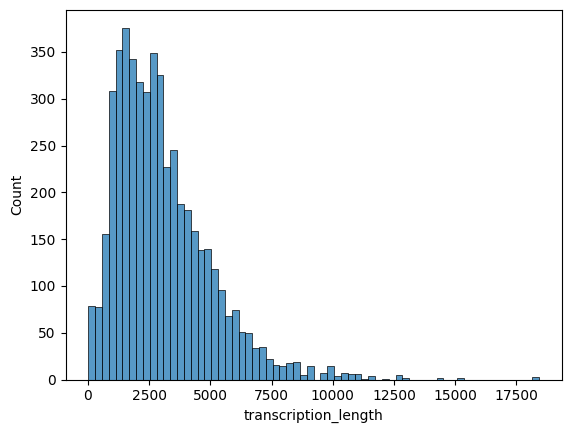

In [46]:
sns.histplot(df["transcription_length"])


In [47]:
df[df['transcription_length'] < 200]

,description,medical_specialty,sample_name,transcription,keywords,transcription_length
24,Blood in urine - Transitional cell cancer of ...,Urology,Urology Consut - 1,"CHIEF COMPLAINT:,",NaN,17.0
142,"Cystourethroscopy, bilateral retrograde pyelo...",Urology,Cystourethroscopy & Retrograde Pyelogram,"PREOPERATIVE DIAGNOSES:,1. Recurrent bladder ...","urology, recurrent bladder tumor, bladder carc...",112.0
166,Normal Circumcision,Urology,Circumcision - 4,The patient tolerated the procedure well and w...,"urology, circumcision, circumferential proxima...",95.0
318,Subcutaneous transposition of the right ulnar...,Surgery,Subcutaneous Transposition of Ulnar Nerve,"PREOPERATIVE DIAGNOSIS: ,1. Right carpal tun...","surgery, subcutaneous transposition, ulnar ner...",62.0
606,Lateral release with lengthening of the ECRB ...,Surgery,Lateral Epicondylitis Release,"PREOPERATIVE DIAGNOSIS: ,Lateral epicondylitis.","surgery, lateral release, ecrb tendon, ecrl, l...",48.0
...,...,...,...,...,...,...
4658,Dobutrex stress test for abnormal EKG,Cardiovascular / Pulmonary,Stress Test Dobutrex,"INDICATIONS:,","cardiovascular / pulmonary, dobutrex stress te...",13.0
4659,Thallium stress test for chest pain.,Cardiovascular / Pulmonary,Stress Test Thallium,"INDICATIONS: ,Chest pain.,STRESS TECHNIQUE:,","cardiovascular / pulmonary, chest pain, ecg st...",45.0
4724,Myocardial perfusion study at rest and stress...,Cardiovascular / Pulmonary,Myocardial Perfusion Imaging - 3,"DIAGNOSIS: ,Shortness of breath. Fatigue and...","cardiovascular / pulmonary, myocardial perfusi...",144.0
4730,"Loculated left effusion, multilobar pneumonia...",Cardiovascular / Pulmonary,Multilobar Pneumonia,"REASON FOR CONSULTATION: , Loculated left effu...","cardiovascular / pulmonary, neck bruits, nasal...",73.0


In [48]:
df.keywords.isna().sum()

1068

In [49]:
df[df['keywords'].isna() & (df['transcription_length'] < 500)].shape

(21, 6)

In [50]:
df = df[~((df['keywords'].isna()) & (df['transcription_length'] < 500))]

In [51]:
df.shape
df['keywords'].isna().sum()

1047

In [57]:
df.groupby('medical_specialty')['transcription'].describe()

,count,unique,top,freq
medical_specialty,,,,
Allergy / Immunology,7,7,"SUBJECTIVE:, This 23-year-old white female pr...",1
Autopsy,7,7,"SUMMARY OF CLINICAL HISTORY:, The patient was...",1
Bariatrics,18,18,"PAST MEDICAL HISTORY:, He has difficulty climb...",1
Cardiovascular / Pulmonary,371,371,"2-D M-MODE: , ,1. Left atrial enlargement wit...",1
Chiropractic,13,13,"PRESENT COMPLAINTS: , The patient is reporting...",1
Consult - History and Phy.,513,513,"SUBJECTIVE:, The patient presents with Mom fo...",1
Cosmetic / Plastic Surgery,27,27,"PREOPERATIVE DIAGNOSES:,1. Nasal obstruction ...",1
Dentistry,27,27,"PREOPERATIVE DIAGNOSIS:, Completely bony impa...",1
Dermatology,29,29,"PROCEDURE: , Skin biopsy, scalp mole.,INDICATI...",1


<Axes: xlabel='count', ylabel='medical_specialty'>

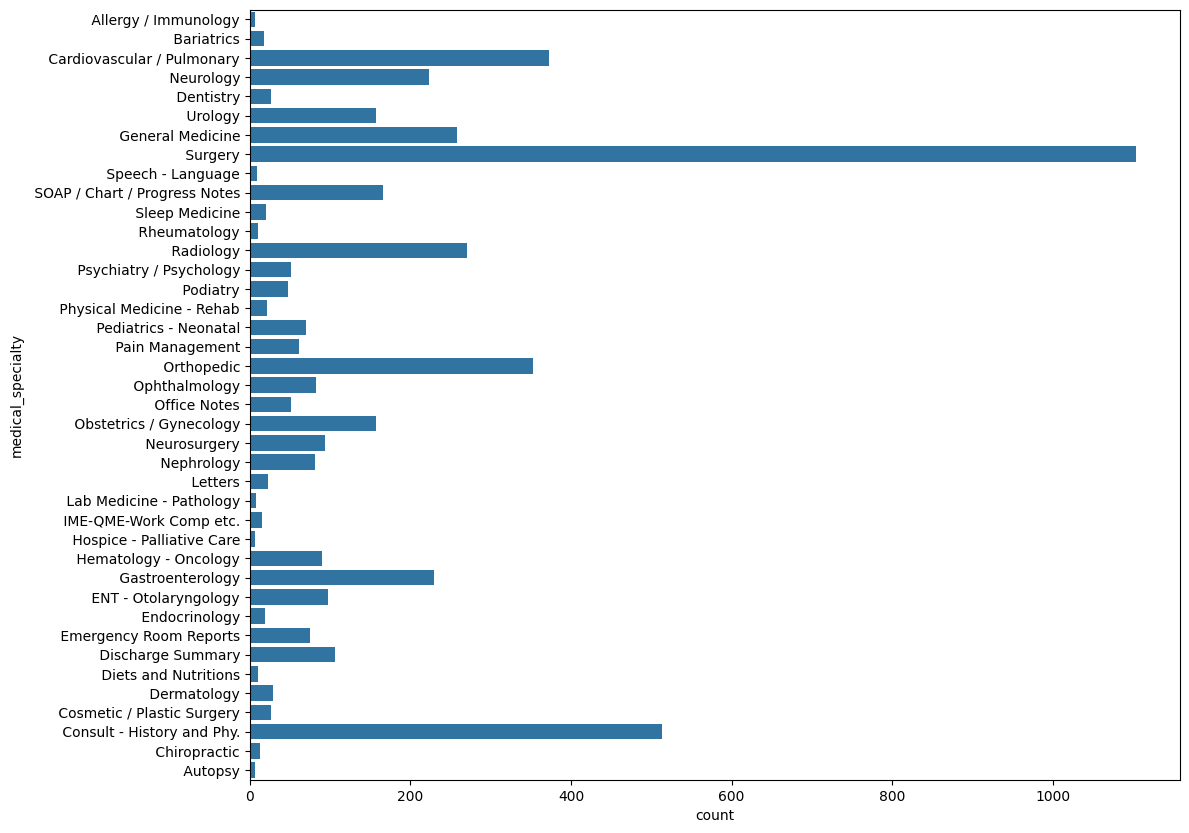

In [56]:
plt.figure(figsize=(12, 10))
sns.countplot(data=df, y='medical_specialty')

Significant class imbalance observed across specialties. Surgery dominates with ~1100 records. This will require mitigation during training — options include undersampling Surgery, oversampling minority classes, or weighted loss functions.

In [58]:
df.groupby('medical_specialty')['transcription'].count().sort_values()

medical_specialty
Hospice - Palliative Care           6
Allergy / Immunology                7
Autopsy                             7
Lab Medicine - Pathology            8
Speech - Language                   9
Rheumatology                       10
Diets and Nutritions               10
Chiropractic                       13
IME-QME-Work Comp etc.             15
Bariatrics                         18
Endocrinology                      19
Sleep Medicine                     20
Physical Medicine - Rehab          21
Letters                            23
Dentistry                          27
Cosmetic / Plastic Surgery         27
Dermatology                        29
Podiatry                           47
Office Notes                       50
Psychiatry / Psychology            51
Pain Management                    60
Pediatrics - Neonatal              70
Emergency Room Reports             75
Nephrology                         81
Ophthalmology                      83
Hematology - Oncology           

Decision made that specialities less than 10 are removed, due to a lack of input when training the model. It's also worth noting that even at 10 the influence is probably negligible to higher scoring specialities. 

In [60]:
specialty_counts = df.groupby('medical_specialty')['transcription'].count()
valid_specialties = specialty_counts[specialty_counts >= 10].index
df = df[df['medical_specialty'].isin(valid_specialties)]

In [61]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords,transcription_length
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431.0
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422.0
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495.0
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618.0
5,Morbid obesity. Laparoscopic antecolic anteg...,Bariatrics,Laparoscopic Gastric Bypass,"PREOPERATIVE DIAGNOSIS: , Morbid obesity.,POST...","bariatrics, gastric bypass, eea anastomosis, r...",4334.0


<Axes: xlabel='transcription_length', ylabel='medical_specialty'>

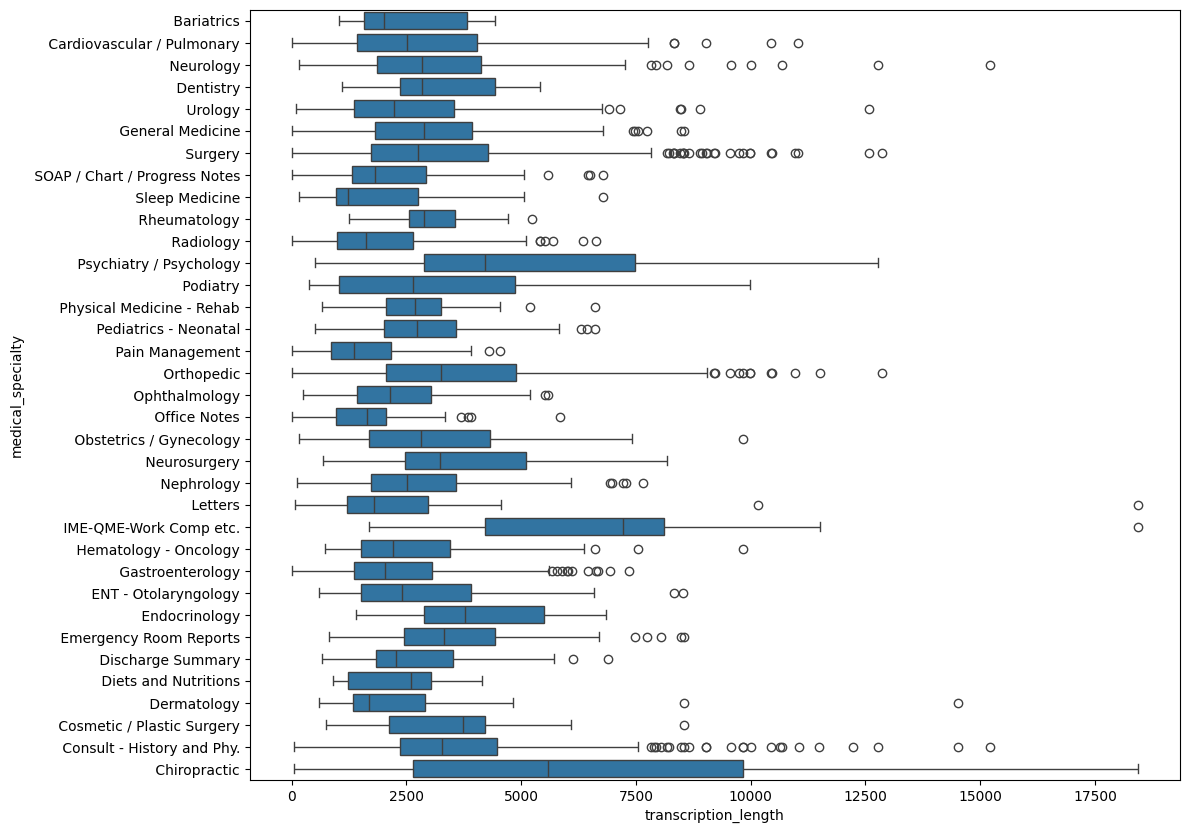

In [62]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df, x='transcription_length', y='medical_specialty')

In [65]:
keywords = df['keywords'].str.split(',').explode().str.strip()
keywords = keywords[keywords != '']

In [66]:
keywords.value_counts()

keywords
surgery                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             1043
orthopedic                                                                                                                                                                                                                                                                                                                                                                                                                                            

Boilerplate text is held in dataframe and needs removing in cleaning stage

In [67]:
keywords_clean = keywords[keywords.str.len() < 50]

In [69]:
keywords_clean.value_counts().head(30)

keywords
surgery                          1043
orthopedic                        307
cardiovascular / pulmonary        277
radiology                         250
consult - history and phy.        220
gastroenterology                  199
neurology                         165
urology                           145
general medicine                  143
soap / chart / progress notes     140
obstetrics / gynecology           133
cervical                          129
laparoscopic                      123
artery                            123
abdomen                           116
incision                          107
anterior                          105
ct                                104
chest                              98
stenosis                           95
bladder                            95
mri                                95
tourniquet                         92
needle                             91
ophthalmology                      86
ent - otolaryngology               85
cat

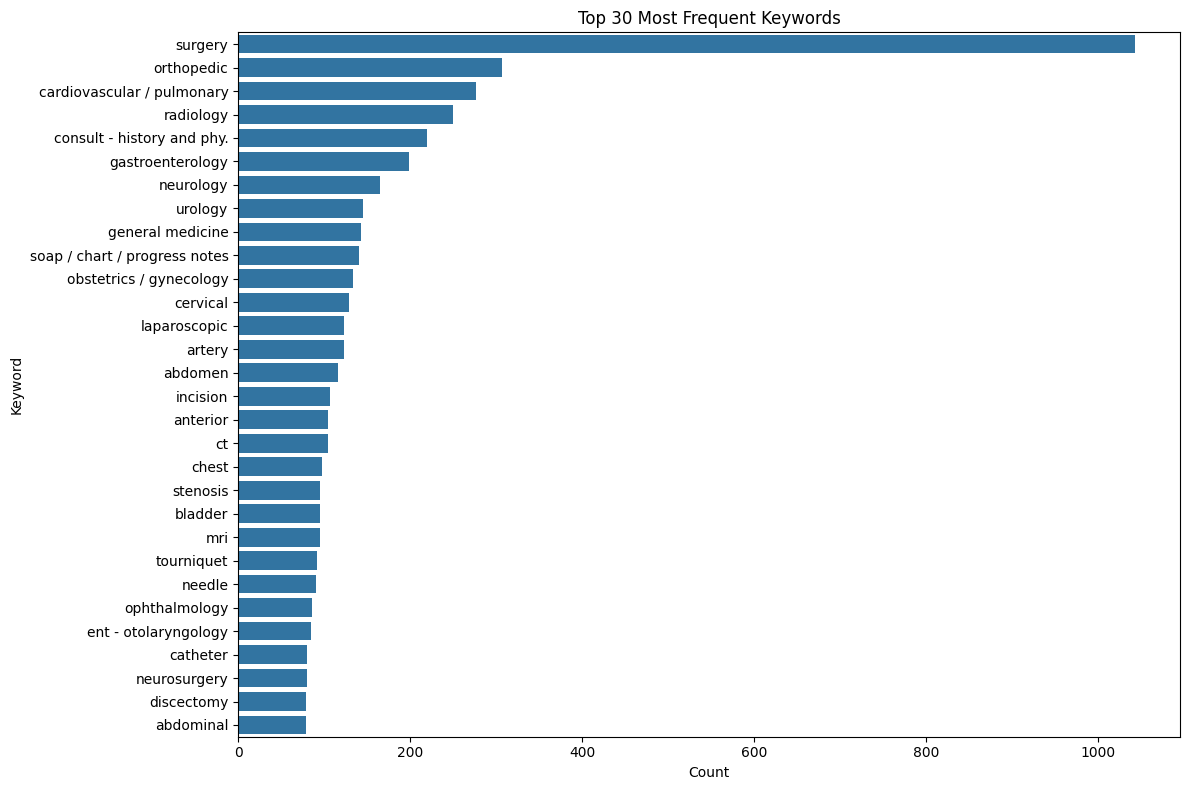

In [70]:
plt.figure(figsize=(12, 8))
sns.barplot(x=keywords_clean.value_counts().head(30).values, 
            y=keywords_clean.value_counts().head(30).index)
plt.title('Top 30 Most Frequent Keywords')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

* Specialty labels — to be filtered out
* Procedural terms — borderline useful
* Anatomical terms — useful as context
* Clinical findings/diagnoses — wwe need this for labelling